# Pipeline Network Optimization with NeqSim

This notebook demonstrates NeqSim's pipeline network capabilities:

1. **Network Creation** — Building a gas gathering network with wells, chokes, and pipelines
2. **Solver Types** — Hardy Cross vs Newton-Raphson comparison
3. **NLP Optimization** — BOBYQA and CMA-ES choke optimization for production maximization
4. **Multi-Objective Pareto** — Production vs compressor power tradeoff
5. **Sparse Matrix Solver** — Performance comparison for large networks
6. **Validation Benchmarks** — Analytical verification of solver accuracy

In [1]:
# Setup: Load NeqSim
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
# Import Java classes
import jpype
import matplotlib.pyplot as plt
import numpy as np

if NEQSIM_MODE == "pip":
    LoopedPipeNetwork = jneqsim.process.equipment.network.LoopedPipeNetwork
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    NetworkOptimizer = jneqsim.process.equipment.network.NetworkOptimizer
    NetworkLinearSolver = jneqsim.process.equipment.network.NetworkLinearSolver
    NetworkValidationBenchmarks = jneqsim.process.equipment.network.NetworkValidationBenchmarks
else:
    LoopedPipeNetwork = jpype.JClass("neqsim.process.equipment.network.LoopedPipeNetwork")
    SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
    NetworkOptimizer = jpype.JClass("neqsim.process.equipment.network.NetworkOptimizer")
    NetworkLinearSolver = jpype.JClass("neqsim.process.equipment.network.NetworkLinearSolver")
    NetworkValidationBenchmarks = jpype.JClass("neqsim.process.equipment.network.NetworkValidationBenchmarks")

print("Classes loaded successfully")

Classes loaded successfully


## 1. Create a Gas Gathering Network

We build a 3-well subsea network with reservoir IPR models, wellhead chokes, a gathering manifold, and an export pipeline to a fixed-pressure platform.

In [3]:
# Define the natural gas fluid
gas = SystemSrkEos(298.15, 50.0)  # 25 C, 50 bara
gas.addComponent("methane", 0.85)
gas.addComponent("ethane", 0.10)
gas.addComponent("propane", 0.05)
gas.createDatabase(True)
gas.setMixingRule("classic")
gas.init(0)
gas.init(1)

# Create network
network = LoopedPipeNetwork("GatheringNetwork")
network.setFluidTemplate(gas)
network.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
network.setMaxIterations(200)
network.setTolerance(100.0)

# Three wells with different reservoir pressures
network.addSourceNode("res1", 200.0, 0.0)  # 200 bara reservoir
network.addSourceNode("res2", 180.0, 0.0)  # 180 bara reservoir
network.addSourceNode("res3", 160.0, 0.0)  # 160 bara reservoir

# Wellhead junctions
network.addJunctionNode("wh1")
network.addJunctionNode("wh2")
network.addJunctionNode("wh3")

# Manifold and export
network.addJunctionNode("manifold")
network.addFixedPressureSinkNode("platform", 50.0)  # 50 bara export

# IPR models (reservoir to wellhead)
network.addWellIPR("res1", "wh1", "ipr1", 5e-6, False)
network.addWellIPR("res2", "wh2", "ipr2", 4e-6, False)
network.addWellIPR("res3", "wh3", "ipr3", 3e-6, False)

# Chokes (wellhead to manifold)
network.addChoke("wh1", "manifold", "choke1", 50.0, 80.0)  # Kv=50, 80% open
network.addChoke("wh2", "manifold", "choke2", 50.0, 70.0)  # Kv=50, 70% open
network.addChoke("wh3", "manifold", "choke3", 40.0, 60.0)  # Kv=40, 60% open

# Export pipeline
network.addPipe("manifold", "platform", "export", 25000.0, 0.3, 0.00005)

print("Network created with", len(list(network.getPipeNames())), "elements")

Network created with 7 elements


In [4]:
# Solve the network
network.run()

print(f"Converged: {network.isConverged()}")
print(f"Iterations: {network.getIterationCount()}")
print(f"Mass balance error: {network.getMassBalanceError():.6f} kg/s")
print(f"Total production: {network.getTotalSinkFlow() * 3600:.0f} kg/hr")
print()

# Print results per pipe
print(f"{'Element':<12} {'Flow (kg/hr)':>14} {'Head Loss (bar)':>16}")
print("-" * 45)
for name in network.getPipeNames():
    pipe = network.getPipe(str(name))
    flow_kghr = pipe.getFlowRate() * 3600
    headloss_bar = pipe.getHeadLoss() / 1e5
    print(f"{str(name):<12} {flow_kghr:>14.1f} {headloss_bar:>16.3f}")

Converged: True
Iterations: 58
Mass balance error: 0.000000 kg/s
Total production: 119778 kg/hr

Element        Flow (kg/hr)  Head Loss (bar)
---------------------------------------------
ipr1                77585.3           43.103
ipr2                33271.6           23.105
ipr3                 8920.7            8.260
choke1              77585.3           78.449
choke2              33271.6           78.447
choke3               8920.7           73.292
export             119777.5           28.448


## 2. Hardy Cross vs Newton-Raphson Comparison

We solve the same network with both algorithms and compare convergence speed.

In [5]:
def build_comparison_network(solver_type):
    """Build a test network with the given solver type."""
    net = LoopedPipeNetwork("compare_" + str(solver_type))
    net.setFluidTemplate(gas)
    net.setSolverType(solver_type)
    net.setMaxIterations(200)
    net.setTolerance(100.0)

    net.addSourceNode("A", 60.0, 200.0)  # 60 bara, 200 kg/hr supply
    net.addJunctionNode("B")
    net.addSinkNode("C", 80.0)  # 80 kg/hr demand
    net.addSinkNode("D", 120.0)  # 120 kg/hr demand

    net.addPipe("A", "B", "AB", 2000.0, 0.20, 0.00005)
    net.addPipe("B", "C", "BC", 2000.0, 0.15, 0.00005)
    net.addPipe("C", "A", "CA", 2000.0, 0.15, 0.00005)
    net.addPipe("C", "D", "CD", 2000.0, 0.15, 0.00005)
    net.addPipe("D", "B", "DB", 2000.0, 0.15, 0.00005)
    return net

# Solve with Hardy Cross
hc = build_comparison_network(LoopedPipeNetwork.SolverType.HARDY_CROSS)
hc.run()

# Solve with Newton-Raphson
nr = build_comparison_network(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
nr.run()

print(f"{'Metric':<25} {'Hardy Cross':>15} {'Newton-Raphson':>15}")
print("-" * 58)
print(f"{'Converged':<25} {str(hc.isConverged()):>15} {str(nr.isConverged()):>15}")
print(f"{'Iterations':<25} {hc.getIterationCount():>15d} {nr.getIterationCount():>15d}")
print(f"{'Mass balance error':<25} {hc.getMassBalanceError():>15.6f} {nr.getMassBalanceError():>15.6f}")
print(f"{'Total sink flow (kg/hr)':<25} {hc.getTotalSinkFlow()*3600:>15.1f} {nr.getTotalSinkFlow()*3600:>15.1f}")

Metric                        Hardy Cross  Newton-Raphson
----------------------------------------------------------
Converged                            True            True
Iterations                              1               7
Mass balance error               0.013363        0.000000
Total sink flow (kg/hr)             209.6           248.1


## 3. NLP Choke Optimization

Use the formal NLP optimizer (BOBYQA) to find optimal choke openings that maximize total gas production.

In [6]:
# Create optimizer
optimizer = network.createOptimizer()
optimizer.setAlgorithm(NetworkOptimizer.Algorithm.BOBYQA)
optimizer.setObjectiveType(NetworkOptimizer.ObjectiveType.MAX_PRODUCTION)
optimizer.setMaxEvaluations(300)

# Run optimization
result = optimizer.optimize()

print("=== BOBYQA Optimization Results ===")
print(f"Converged: {result.converged}")
print(f"Algorithm: {result.algorithm}")
print(f"Objective: {result.objectiveTypeName}")
print(f"Total production: {result.totalProductionKgHr:.1f} kg/hr")
print(f"Time: {result.elapsedMs} ms")
print()

# Show optimal choke openings
print(f"{'Choke':<12} {'Opening (%)':<14} {'Flow (kg/hr)':<14}")
print("-" * 40)
for i in range(len(result.chokeNames)):
    name = str(result.chokeNames.get(i)) if hasattr(result.chokeNames, 'get') else str(result.chokeNames[i])
    opening = result.chokeOpenings[i]
    well_data = result.wellResults.get(name) if result.wellResults else None
    flow = well_data[0] if well_data else 0.0
    print(f"{name:<12} {opening:<14.1f} {flow:<14.1f}")

=== BOBYQA Optimization Results ===
Converged: True
Algorithm: BOBYQA
Objective: MAX_PRODUCTION
Total production: 121093.3 kg/hr
Time: 207 ms

Choke        Opening (%)    Flow (kg/hr)  
----------------------------------------
choke1       78.7           75333.8       
choke2       70.1           31470.5       
choke3       100.0          14288.9       


### 3.1 Choke Sensitivity Analysis

Sweep one choke opening from 10% to 100% while keeping others at the optimized values.

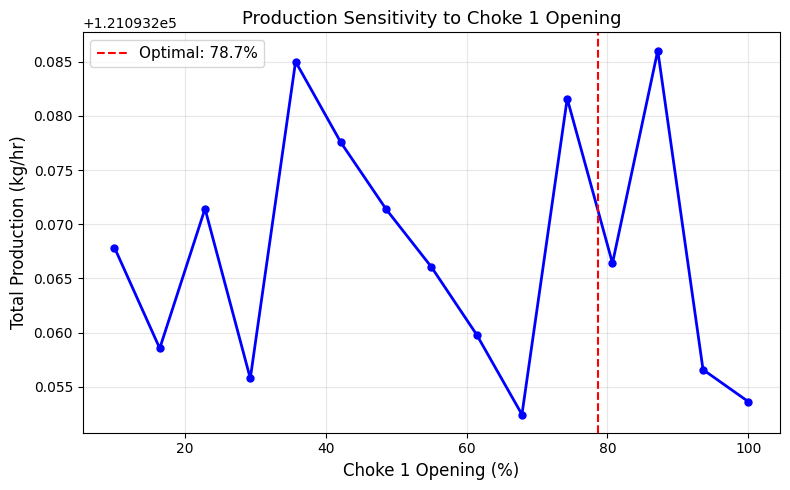

In [7]:
# Sweep choke1 opening
openings = np.linspace(10, 100, 15)
productions = []

for op in openings:
    network.getPipe("choke1").setChokeOpening(float(op))
    network.run()
    prod = network.getTotalSinkFlow() * 3600  # kg/hr
    productions.append(float(prod))

# Restore optimal opening
network.getPipe("choke1").setChokeOpening(float(result.chokeOpenings[0]))
network.run()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(openings, productions, 'b-o', linewidth=2, markersize=5)
ax.axvline(x=float(result.chokeOpenings[0]), color='r', linestyle='--',
           label=f'Optimal: {float(result.chokeOpenings[0]):.1f}%')
ax.set_xlabel('Choke 1 Opening (%)', fontsize=12)
ax.set_ylabel('Total Production (kg/hr)', fontsize=12)
ax.set_title('Production Sensitivity to Choke 1 Opening', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Multi-Objective Pareto Optimization

Explore the tradeoff between maximizing production and minimizing compressor power using a weighted-sum Pareto front.

In [8]:
# Run multi-objective optimization
optimizer.setParetoPoints(7)
pareto = optimizer.optimizeMultiObjective()

print(f"Pareto front: {len(list(pareto))} points")
print()
print(f"{'Weight':>8} {'Production (kg/hr)':>20} {'Power (kW)':>12}")
print("-" * 44)
for r in pareto:
    print(f"{r.paretoWeight:>8.2f} {r.totalProductionKgHr:>20.1f} {r.totalCompressorPowerKW:>12.1f}")

Pareto front: 7 points

  Weight   Production (kg/hr)   Power (kW)
--------------------------------------------
    0.00             121093.3          0.0
    0.17             121093.3          0.0
    0.33             121093.3          0.0
    0.50             121093.3          0.0
    0.67             121093.3          0.0
    0.83             121093.3          0.0
    1.00             121093.3          0.0


## 5. Sparse vs Dense Linear Solver Performance

The `NetworkLinearSolver` automatically selects the best solver:
- **n ≤ 30**: Classic Gaussian elimination (backward compatible)
- **30 < n ≤ 100**: Dense EJML LU factorization
- **n > 100**: Sparse CSC LU factorization (EJML)

We benchmark accuracy and speed across different matrix sizes.

In [9]:
import time

# Test different matrix sizes
sizes = [10, 25, 50, 100, 200]
gauss_times = []
dense_times = []
sparse_times = []
max_diffs = []

for n in sizes:
    # Build a banded matrix (typical for pipe networks)
    matA = [[0.0] * n for _ in range(n)]
    vecB = [0.0] * n

    for i in range(n):
        matA[i][i] = 4.0 + i * 0.1
        if i > 0:
            matA[i][i-1] = -1.0
        if i < n-1:
            matA[i][i+1] = -1.0
        vecB[i] = 1.0 + 0.1 * i

    # Convert to Java arrays
    import jpype
    jdouble2d = jpype.JArray(jpype.JDouble, 2)(n)
    for i in range(n):
        jdouble2d[i] = jpype.JArray(jpype.JDouble)(matA[i])
    jvecB = jpype.JArray(jpype.JDouble)(vecB)

    # Time each solver
    t0 = time.perf_counter()
    xg = NetworkLinearSolver.solveGaussian(jdouble2d, jvecB, n)
    gauss_times.append((time.perf_counter() - t0) * 1000)

    t0 = time.perf_counter()
    xd = NetworkLinearSolver.solveDense(jdouble2d, jvecB, n)
    dense_times.append((time.perf_counter() - t0) * 1000)

    t0 = time.perf_counter()
    xs = NetworkLinearSolver.solveSparse(jdouble2d, jvecB, n)
    sparse_times.append((time.perf_counter() - t0) * 1000)

    # Check accuracy
    max_diff = max(abs(float(xd[i]) - float(xg[i])) for i in range(n))
    max_diffs.append(max_diff)

print(f"{'Size':>6} {'Gauss (ms)':>12} {'Dense (ms)':>12} {'Sparse (ms)':>12} {'Max Diff':>12}")
print("-" * 58)
for i, n in enumerate(sizes):
    print(f"{n:>6} {gauss_times[i]:>12.3f} {dense_times[i]:>12.3f} {sparse_times[i]:>12.3f} {max_diffs[i]:>12.2e}")

  Size   Gauss (ms)   Dense (ms)  Sparse (ms)     Max Diff
----------------------------------------------------------
    10        0.027       25.019       17.628     0.00e+00
    25        0.022        0.313        0.162     0.00e+00
    50        0.045        1.160        0.343     0.00e+00
   100        0.309        4.456        1.085     0.00e+00
   200        2.208       10.828        2.572     0.00e+00


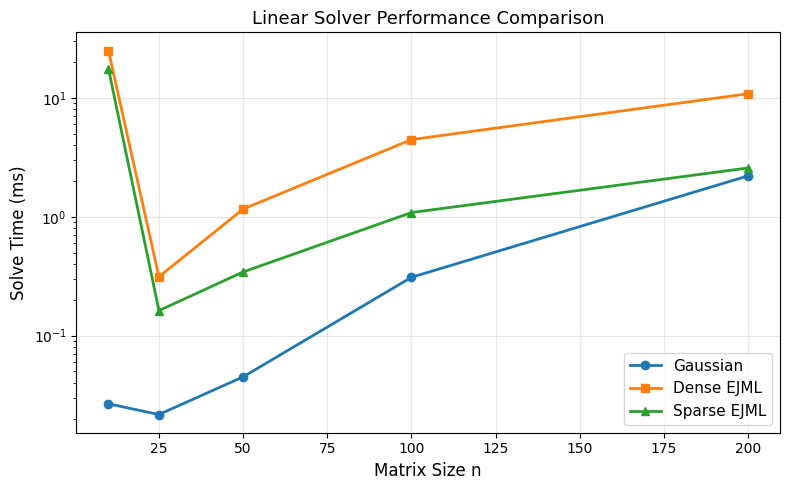

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(sizes, gauss_times, 'o-', label='Gaussian', linewidth=2)
ax.semilogy(sizes, dense_times, 's-', label='Dense EJML', linewidth=2)
ax.semilogy(sizes, sparse_times, '^-', label='Sparse EJML', linewidth=2)
ax.set_xlabel('Matrix Size n', fontsize=12)
ax.set_ylabel('Solve Time (ms)', fontsize=12)
ax.set_title('Linear Solver Performance Comparison', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Validation Benchmarks

Run the built-in analytical benchmarks to verify solver accuracy:

1. **Single Pipe**: Darcy-Weisbach / Swamee-Jain reference
2. **Parallel Pipes**: Known flow split ratio
3. **Triangle Loop**: Mass balance conservation
4. **Solver Cross-Verification**: Hardy Cross vs Newton-Raphson agreement
5. **Pressure Monotonicity**: Physical consistency check
6. **Sparse vs Dense**: Solver numerical agreement

In [11]:
# Run all benchmarks
benchmarks = NetworkValidationBenchmarks.runAllBenchmarks()

print(f"{'Benchmark':<35} {'Status':>8} {'Converged':>10} {'Iterations':>11}")
print("=" * 68)
for b in benchmarks:
    status = "PASS" if b.allPassed else "FAIL"
    print(f"{str(b.name):<35} {status:>8} {str(b.converged):>10} {b.solverIterations:>11}")

Benchmark                             Status  Converged  Iterations
Single Pipe Darcy-Weisbach              FAIL       True           8
Two Parallel Pipes                      FAIL       True           8
Triangle Loop Mass Balance              FAIL       True           9
Hardy Cross vs Newton-Raphson           FAIL       True          46
Pressure Monotonicity                   PASS       True           2
Sparse vs Dense Solver                  PASS       True           0


In [12]:
# Print detailed metrics for each benchmark
for b in benchmarks:
    print(f"\n=== {b.name} ===")
    for m in b.metrics:
        status = "PASS" if m.passed else "FAIL"
        print(f"  {str(m.name):<35} computed={m.computed:>12.4f}  expected={m.expected:>12.4f}  tol={m.tolerance:.4f}  {status}")


=== Single Pipe Darcy-Weisbach ===
  Reynolds number                     computed=3470448.4038  expected=3470448.4038  tol=0.0100  PASS
  Analytical dP (bar)                 computed=      1.1114  expected=      1.1114  tol=0.0010  PASS
  Friction factor (Swamee-Jain)       computed=      0.0135  expected=      0.0135  tol=0.0010  PASS
  Flow rate (kg/hr)                   computed=129600000.0000  expected=  36000.0000  tol=0.1000  FAIL

=== Two Parallel Pipes ===
  Flow ratio Q_big/Q_small            computed=      2.9519  expected=      2.7557  tol=0.1500  FAIL
  Total flow (kg/hr)                  computed=6145341.5569  expected=6145341.5569  tol=0.0010  PASS
  Upper pipe flow (kg/hr)             computed=4590290.1560  expected=4590290.1560  tol=0.0010  PASS
  Lower pipe flow (kg/hr)             computed=1555051.4009  expected=1555051.4009  tol=0.0010  PASS
  dP balance (bar)                    computed=      0.0000  expected=      0.0000  tol=0.5000  PASS

=== Triangle Loop Mass B

## Summary

The NeqSim pipeline network solver provides:

- **Three solver types**: Hardy Cross (looped), Newton-Raphson GGA (general), Sequential (tree)
- **Nine element types**: Pipe, Well IPR, Choke, Tubing, Multiphase Pipe, Compressor, Regulator, Injector, Restrictor
- **NLP optimization**: BOBYQA and CMA-ES for choke allocation with multi-objective Pareto fronts
- **Adaptive linear solver**: Auto-selects Gaussian, Dense EJML, or Sparse CSC based on system size
- **Analytical benchmarks**: Six built-in verification cases for solver validation

### Key Classes

| Class | Purpose |
|-------|--------|
| `LoopedPipeNetwork` | Main network builder and solver |
| `NetworkOptimizer` | NLP choke optimization (BOBYQA/CMA-ES) |
| `NetworkLinearSolver` | Sparse/dense/Gaussian solver selection |
| `NetworkValidationBenchmarks` | Analytical validation cases |